# Veri Analizi İçin Python


Web sitesi: [rcs.bu.edu](http://www.bu.edu/tech/support/research/) <br>
Eğitim materyalleri: [http://rcs.bu.edu/examples/python/data_analysis](http://rcs.bu.edu/examples/python/data_analysis)

In [1]:
#Import Python Libraries
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Enable inline plotting
%matplotlib inline

Pandas, çoğunlukla şunlarla ilgilenen bir Python paketidir:
- **Seri** (1 boyutlu homojen dizi)
- **DataFrame** (2 boyutlu etiketli heterojen dizi)
- **Panel** (genel 3 boyutlu dizi)

### Pandas Serileri

Pandas *Serisi*, aynı tipte verileri (tamsayılar, dizeler, ondalık sayılar, Python nesneleri vb.) içeren tek boyutlu etiketli bir dizidir. Eksen etiketlerine genellikle *indeks* denir.

In [2]:
# Example of creating Pandas series :
s1 = pd.Series( [-3,-1,1,3,5] )
s1

,0
0,-3
1,-1
2,1
3,3
4,5


Herhangi bir indeks geçirmedik, bu yüzden varsayılan olarak 0'dan len(veri)-1'e kadar indeksler atadı.

In [5]:
# View index values
print(s1.index)

RangeIndex(start=0, stop=5, step=1)


In [3]:
# Creating Pandas series with index:
s2 = pd.Series( np.random.randn(5), index=['a', 'b', 'c', 'd', 'e'] )
print(s2)

a    0.427008
b   -0.614736
c    0.764291
d    0.090687
e   -1.166289
dtype: float64


In [4]:
# View index values
print(s2.index)

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')


In [5]:
# Create a Series from dictionary
data = {'pi': 3.1415, 'e': 2.71828}  # dictionary
print(data)
s3 = pd.Series ( data )
print(s3)

{'pi': 3.1415, 'e': 2.71828}
pi    3.14150
e     2.71828
dtype: float64


In [6]:
# reordering the elements
s4 = pd.Series ( data, index = ['e', 'pi', 'tau'])
print(s4)

e      2.71828
pi     3.14150
tau        NaN
dtype: float64


NAN (bir sayı değil) - Pandas'ta eksik bir değeri belirtmek için kullanılır.

In [10]:
s1[:2] # First 2 elements


,0
0,-3
1,-1


In [11]:
print( s1[ [2,1,0]])  # Elements out of order

2    1
1   -1
0   -3
dtype: int64


In [12]:
type(s1)

pandas.core.series.Series

In [7]:
# Series can be used as a usual one-dimentional array (ndarray):
print("Median:" , s4.median())

Median: 2.9298900000000003


In [14]:
s1[s1 > 0]

,0
2,1
3,3
4,5


In [15]:
# numpy methods can be used on series as usual:
s4[s4 > s4.median()]

,0
pi,3.1415


#### Nitelikler ve Metotlar:

| Nitelik/Metot | Açıklama |
|-----|-----|
| dtype | serideki değerlerin veri tipi |
| empty | seri boşsa Doğru |
| size | eleman sayısı |
| values | Değerleri ndarray olarak döndürür |
| head() | İlk n eleman |
| tail() | Son n eleman |

Tüm nitelikleri ve metotları görmek için *dir(s1)* komutunu çalıştırın.

*Alıştırma*

In [16]:
dir(s1)

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__bool__',
 '__class__',
 '__column_consortium_standard__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__or__',
 '__pandas_priority__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__

In [ ]:
# Create a series of your choice and explore it
# <your code goes here >
# mys = pd.Series(  ...  )
# print(mys)

In [ ]:
# mys.head()

In [ ]:
# mys.empty

### Pandas DataFrame

Pandas *DataFrame*, etiketli satır ve sütunlara (eksenlere) sahip, iki boyutlu, boyutu değiştirilebilir, heterojen tablo şeklindeki bir veri yapısıdır. Python Seri nesnelerini depolamak için bir sözlük benzeri bir konteyner olarak düşünülebilir.

In [17]:
d =  pd.DataFrame({ 'Name': pd.Series(['Alice','Bob','Chris']),
                  'Age': pd.Series([ 21,25,23]) } )
print(d)

    Name  Age
0  Alice   21
1    Bob   25
2  Chris   23


In [18]:
d2 = pd.DataFrame(np.array([['Alice','Bob','Chris'],[ 21,25,23]]).T, columns=['Name','Age'])

In [19]:
d2

,Name,Age
0,Alice,21
1,Bob,25
2,Chris,23


In [20]:
#Add a new column:
d['height'] = pd.Series([5.2,6.0,5.6])
d

,Name,Age,height
0,Alice,21,5.2
1,Bob,25,6.0
2,Chris,23,5.6


In [8]:
#Read csv file
df = pd.read_csv("http://rcs.bu.edu/examples/python/DataAnalysis/Salaries.csv")
#

In [9]:
df = pd.read_csv("Salaries.csv")

In [10]:
df

,rank,discipline,phd,service,sex,salary
0,Prof,B,56,49,Male,186960
1,Prof,A,12,6,Male,93000
2,Prof,A,23,20,Male,110515
3,Prof,A,40,31,Male,131205
4,Prof,B,20,18,Male,104800
...,...,...,...,...,...,...
73,Prof,B,18,10,Female,105450
74,AssocProf,B,19,6,Female,104542
75,Prof,B,17,17,Female,124312
76,Prof,A,28,14,Female,109954


Veriler üzerinde herhangi bir analiz yapmadan önce:

*   Verilerin doğru bir şekilde içe aktarılıp aktarılmadığını kontrol edin
*   Her sütunun türünü kontrol edin
*   Her sütunun kaç eksik değere sahip olduğunu kontrol edin

Daha sonra verileri dikkatlice hazırlamalıyız:

*   Analizimiz için ihtiyacımız olmayan sütunları kaldırın
*   Gerekirse sütunları yeniden adlandırın
*   Onlarla çalışmayı kolaylaştırmak için sütunları yeniden düzenleyin
*   Gerekirse yeni sütunlar oluşturun veya mevcut olanları değiştirin (örn. farklı birimlere dönüştürün)

In [11]:
#Display a few first records
df.head(10)

,rank,discipline,phd,service,sex,salary
0,Prof,B,56,49,Male,186960
1,Prof,A,12,6,Male,93000
2,Prof,A,23,20,Male,110515
3,Prof,A,40,31,Male,131205
4,Prof,B,20,18,Male,104800
5,Prof,A,20,20,Male,122400
6,AssocProf,A,20,17,Male,81285
7,Prof,A,18,18,Male,126300
8,Prof,A,29,19,Male,94350
9,Prof,A,51,51,Male,57800


In [12]:
# Display structure of the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   rank        78 non-null     object
 1   discipline  78 non-null     object
 2   phd         78 non-null     int64 
 3   service     78 non-null     int64 
 4   sex         78 non-null     object
 5   salary      78 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 3.8+ KB


Bazen girdi dosyasındaki sütun adları çok uzun olabilir veya özel karakterler içerebilir. Bu durumlarda, bu sütunlarla çalışmayı kolaylaştırmak için onları yeniden adlandırmamız gerekir.

In [27]:
# Let's create a copy of this dataframe with a new column names
# If we do not want to create a new data frame, we can add inplace=True argument
df_new =df.rename(columns={
        'discipline': 'subject',
        'sex': 'gender'
    })

---
*Alıştırma*

In [28]:
#Display first 10 records
df_new.head(10)

,rank,subject,phd,service,gender,salary
0,Prof,B,56,49,Male,186960
1,Prof,A,12,6,Male,93000
2,Prof,A,23,20,Male,110515
3,Prof,A,40,31,Male,131205
4,Prof,B,20,18,Male,104800
5,Prof,A,20,20,Male,122400
6,AssocProf,A,20,17,Male,81285
7,Prof,A,18,18,Male,126300
8,Prof,A,29,19,Male,94350
9,Prof,A,51,51,Male,57800


In [29]:
#Display first 20 records
df_new.head(20)

,rank,subject,phd,service,gender,salary
0,Prof,B,56,49,Male,186960
1,Prof,A,12,6,Male,93000
2,Prof,A,23,20,Male,110515
3,Prof,A,40,31,Male,131205
4,Prof,B,20,18,Male,104800
5,Prof,A,20,20,Male,122400
6,AssocProf,A,20,17,Male,81285
7,Prof,A,18,18,Male,126300
8,Prof,A,29,19,Male,94350
9,Prof,A,51,51,Male,57800


In [31]:
#Display the last 5 records
df_new.tail()

,rank,subject,phd,service,gender,salary
73,Prof,B,18,10,Female,105450
74,AssocProf,B,19,6,Female,104542
75,Prof,B,17,17,Female,124312
76,Prof,A,28,14,Female,109954
77,Prof,A,23,15,Female,109646


---

### Veri Keşfi

In [32]:
#Identify the type of df object
type(df)

pandas.core.frame.DataFrame

In [33]:
#Check the type of a column "salary"
df['salary'].dtype

dtype('int64')

In [35]:
#List the types of all columns
df_new.dtypes

,0
rank,object
subject,object
phd,int64
service,int64
gender,object
salary,int64


In [36]:
#List the column names
df.columns

Index(['rank', 'discipline', 'phd', 'service', 'sex', 'salary'], dtype='object')

In [37]:
#List the row labels and the column names
df.axes

[RangeIndex(start=0, stop=78, step=1),
 Index(['rank', 'discipline', 'phd', 'service', 'sex', 'salary'], dtype='object')]

In [38]:
#Total number of elements in the Data Frame
df.size

468

In [39]:
#Number of rows and columns
df.shape

(78, 6)

In [40]:
#Output basic statistics for the numeric columns
df.describe()

,phd,service,salary
count,78.000000,78.000000,78.000000
mean,19.705128,15.051282,108023.782051
std,12.498425,12.139768,28293.661022
min,1.000000,0.000000,57800.000000
25%,10.250000,5.250000,88612.500000
50%,18.500000,14.500000,104671.000000
75%,27.750000,20.750000,126774.750000
max,56.000000,51.000000,186960.000000


In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
phd,78.0,19.705128,12.498425,1.0,10.25,18.5,27.75,56.0
service,78.0,15.051282,12.139768,0.0,5.25,14.5,20.75,51.0
salary,78.0,108023.782051,28293.661022,57800.0,88612.50,104671.0,126774.75,186960.0


*Yardım al*
df.describe?

In [42]:
df.describe?

In [43]:
# Create a new column
df = df.assign( salary_k = lambda x: x.salary/1000.0)
df.head(10)

,rank,discipline,phd,service,sex,salary,salary_k
0,Prof,B,56,49,Male,186960,186.960
1,Prof,A,12,6,Male,93000,93.000
2,Prof,A,23,20,Male,110515,110.515
3,Prof,A,40,31,Male,131205,131.205
4,Prof,B,20,18,Male,104800,104.800
5,Prof,A,20,20,Male,122400,122.400
6,AssocProf,A,20,17,Male,81285,81.285
7,Prof,A,18,18,Male,126300,126.300
8,Prof,A,29,19,Male,94350,94.350
9,Prof,A,51,51,Male,57800,57.800


In [44]:
# Check how many unique values in a column
df['rank'].unique()

array(['Prof', 'AssocProf', 'AsstProf'], dtype=object)

In [45]:
df['discipline'].unique()

array(['B', 'A'], dtype=object)

In [46]:
# Get frequency table for a categorical or binary column
df['rank'].value_counts()

,count
rank,
Prof,46
AsstProf,19
AssocProf,13


In [47]:
# Get a proportion table
df['rank'].value_counts()/sum(df['rank'].value_counts())

,count
rank,
Prof,0.589744
AsstProf,0.243590
AssocProf,0.166667


In [48]:
#Alternatively we can use pandas function crosstab()
pd.crosstab(index=df['rank'], columns="count")

col_0,count
rank,
AssocProf,13
AsstProf,19
Prof,46


In [ ]:
# Two-way tables
pd.crosstab(index=df['rank'], columns=df['discipline'], margins=True)

---

In [50]:
#Extract a column by name
df['rank'].head()

,rank
0,Prof
1,Prof
2,Prof
3,Prof
4,Prof


In [52]:
# If the column name does not contain spaces or other special characters and does not collide with data frame methods, we can use a dot notation
df.sex.head()

,sex
0,Male
1,Male
2,Male
3,Male
4,Male


In [53]:
# Calculate median number of service years
df.service.median()

14.5

---

In [ ]:
# Maaş sütunu için temel istatistikleri hesaplayın (describe() metodunu kullanın)
# <kodunuz buraya>

In [ ]:
# Maaş sütunundaki değer sayısını hesaplayın (count() metodunu kullanın)
# <kodunuz buraya>

In [ ]:
# Calculate the average (mean) salary

---

In [13]:
#Group data using rank
df_rank = df.groupby('rank')

In [14]:
df_rank

In [15]:
#Calculate mean of all numeric columns for the grouped object
df_rank.mean(numeric_only=True)

,phd,service,salary
rank,,,
AssocProf,15.076923,11.307692,91786.230769
AsstProf,5.052632,2.210526,81362.789474
Prof,27.065217,21.413043,123624.804348


In [16]:
# Most of the time, the "grouping" object is not stored, but is used as a step in getting a summary:
df.groupby('sex').mean(numeric_only=True)

,phd,service,salary
sex,,,
Female,16.512821,11.564103,101002.410256
Male,22.897436,18.538462,115045.153846


In [17]:
#Calculate the mean salary for men and women. The following produce Pandas Series (single brackets around salary)
df.groupby('sex')['salary'].mean()

,salary
sex,
Female,101002.410256
Male,115045.153846


In [18]:
# If we use double brackets Pandas will produce a DataFrame
df.groupby('sex')[['salary']].mean()

,salary
sex,
Female,101002.410256
Male,115045.153846


In [ ]:
# Group using 2 variables - sex and rank:
df.groupby(['rank','sex'], sort=True)[['salary']].mean()

---

In [ ]:
# Verileri disipline göre gruplandırın ve her grup için ortalama maaşı bulun

---

In [ ]:
### Filtreleme

In [ ]:
df_sub.axes

In [ ]:
#Select data for female professors
df_w = df[ df.sex == 'Female']
df_w.head()

In [ ]:
# To subset one column using a condition in another columns use method "where"
df.salary.where(df.sex=='Female').dropna().head(6)

---

In [ ]:
# Filtreleme kullanarak, A disiplini için maaşın ortalama değerini bulun

In [ ]:
# Zorluk:
# Sadece yüksek maaşlı ( > 100K) gözlemleri ayıklayın (filtreleyin) ve her grupta kaç kadın ve erkek profesör olduğunu bulun

---

In [ ]:
### Veri dilimleme ve gruplama

In [ ]:
#Check data type of the result
type(salary)

In [ ]:
#Look at the first few elements of the output
salary.head()

In [ ]:
#Select column salary and make the output to be a data frame
df2 = df[['salary']]

In [ ]:
#Check the type
type(df2)

In [ ]:
#Select a subset of rows (based on their position):
# Note 1: The location of the first row is 0
# Note 2: The last value in the range is not included
df[0:10]

In [ ]:
#If we want to select both rows and columns we can use method .loc
df.loc[10:20,['rank', 'sex','salary']]

In [ ]:
df_sub.head(15)

In [ ]:
#Let's see what we get for our df_sub data frame
# Method .loc subset the data frame based on the labels:
df_sub.loc[10:20,['rank','sex','salary']]

In [ ]:
#  Unlike method .loc, method iloc selects rows (and columns) by poistion:
df_sub.iloc[10:20, [0,3,4,5]]

### Verileri Sıralama

In [ ]:
#Sort the data frame by yrs.service and create a new data frame
df_sorted = df.sort_values(by = 'service')
df_sorted.head()

In [ ]:
#Sort the data frame by yrs.service and overwrite the original dataset
df.sort_values(by = 'service', ascending = False, inplace = True)
df.head()

In [ ]:
# Restore the original order (by sorting using index)
df.sort_index(axis=0, ascending = True, inplace = True)
df.head()

*Alıştırma*

In [ ]:
# Veri çerçevesini maaşa göre (azalan sırada) sıralayın ve çıktının ilk birkaç kaydını (head) görüntüleyin

---

In [ ]:
#Sort the data frame using 2 or more columns:
df_sorted = df.sort_values(by = ['service', 'salary'], ascending = [True,False])
df_sorted.head(10)

### Eksik Değerler

In [60]:
# Read a dataset with missing values
flights = pd.read_csv("http://rcs.bu.edu/examples/python/DataAnalysis/flights.csv")
flights.head()

,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
0,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0
1,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,5.0,33.0
2,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0
3,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,5.0,54.0
4,2013,1,1,554.0,-4.0,740.0,12.0,UA,N39463,1696,EWR,ORD,150.0,719,5.0,54.0


In [61]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160754 entries, 0 to 160753
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   year       160754 non-null  int64  
 1   month      160754 non-null  int64  
 2   day        160754 non-null  int64  
 3   dep_time   158418 non-null  float64
 4   dep_delay  158418 non-null  float64
 5   arr_time   158275 non-null  float64
 6   arr_delay  157927 non-null  float64
 7   carrier    160754 non-null  object 
 8   tailnum    159321 non-null  object 
 9   flight     160754 non-null  int64  
 10  origin     160754 non-null  object 
 11  dest       160754 non-null  object 
 12  air_time   157927 non-null  float64
 13  distance   160754 non-null  int64  
 14  hour       158418 non-null  float64
 15  minute     158418 non-null  float64
dtypes: float64(7), int64(5), object(4)
memory usage: 19.6+ MB


In [ ]:
# Select the rows that have at least one missing value
flights[flights.isnull().any(axis=1)].head()

In [ ]:
# Filter all the rows where arr_delay value is missing:
flights1 = flights[ flights['arr_delay'].notnull( )]
flights1.head()

In [ ]:
# Remove all the observations with missing values
flights2 = flights.dropna()

In [ ]:
# Fill missing values with zeros
nomiss =flights['dep_delay'].fillna(0)
nomiss.isnull().any()

---

In [ ]:
# dep_delay ve arr_delay sütunlarında kaç tane eksik veri olduğunu sayın

---

In [ ]:
### Yaygın Toplama Fonksiyonları:

|Fonksiyon|Açıklama
|-------|--------
|min | minimum
|max | maksimum
|count | boş olmayan gözlem sayısı
|sum | değerlerin toplamı
|mean | değerlerin aritmetik ortalaması
|median | medyan
|mad | ortalama mutlak sapma
|mode | mod
|prod | değerlerin çarpımı
|std | standart sapma
|var | yansız varyans

In [ ]:
flights.info()

In [ ]:
# Find mean value for all the columns in the dataset
flights.min()

In [ ]:
# Let's compute summary statistic per a group':
flights.groupby('carrier')['dep_delay'].mean()

In [ ]:
# We can use agg() methods for aggregation:
flights[['dep_delay','arr_delay']].agg(['min','mean','max'])

In [ ]:
# An example of computing different statistics for different columns
flights.agg({'dep_delay':['min','mean',max], 'carrier':['nunique']})

### Temel tanımlayıcı istatistikler

|Fonksiyon|Açıklama
|-------|--------
|min | minimum
|max | maksimum
|mean | değerlerin aritmetik ortalaması
|median | medyan
|mad | ortalama mutlak sapma
|mode | mod
|std | standart sapma
|var | yansız varyans
|sem | ortalamanın standart hatası
|skew| örnek çarpıklık
|kurt|basıklık
|quantile| %değer

In [ ]:
# Convinient describe() function computes a veriety of statistics
flights.dep_delay.describe()

In [ ]:
# find the index of the maximum or minimum value
# if there are multiple values matching idxmin() and idxmax() will return the first match
flights['dep_delay'].idxmin()  #minimum value

In [ ]:
# Count the number of records for each different value in a vector
flights['carrier'].value_counts()

### Grafikler kullanarak verileri keşfedin

In [62]:
#Show graphs withint Python notebook
%matplotlib inline

(array([7.14677085e-06, 8.73494215e-06, 1.74698843e-05, 8.73494215e-06,
        9.52902780e-06, 6.35268520e-06, 3.17634260e-06, 7.94085650e-07]),
 array([ 57800.,  73945.,  90090., 106235., 122380., 138525., 154670.,
        170815., 186960.]),
 <BarContainer object of 8 artists>)

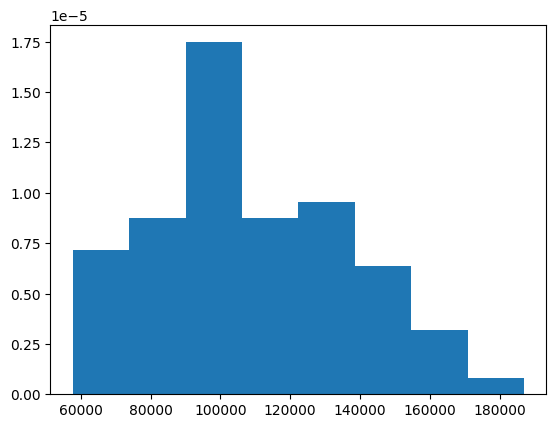

In [63]:
#Use matplotlib to draw a histogram of a salary data
plt.hist(df['salary'],bins=8, density=True)

/tmp/ipykernel_186/28626080.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['salary']);


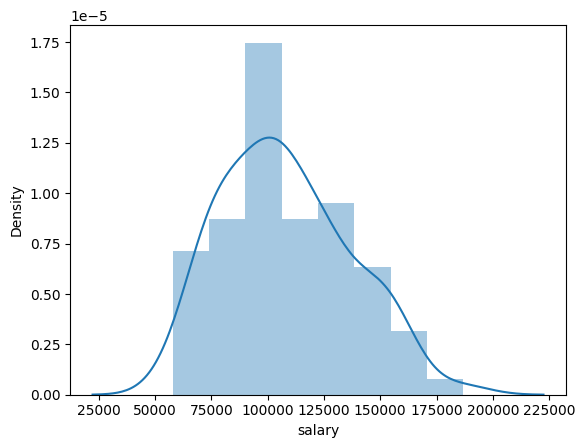

In [64]:
#Use seaborn package to draw a histogram
sns.distplot(df['salary']);

<Axes: xlabel='rank'>

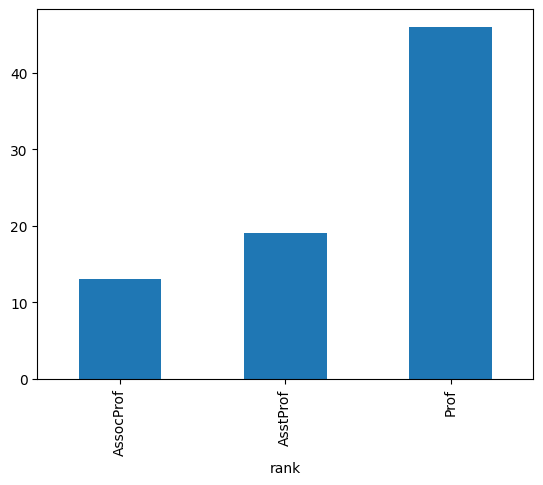

In [65]:
# Use regular matplotlib function to display a barplot
df.groupby(['rank'])['salary'].count().plot(kind='bar')

In [ ]:
# Use seaborn package to display a barplot
sns.set_style("whitegrid")

ax = sns.barplot(x='rank',y ='salary', data=df, estimator=len)

In [ ]:
# Split into 2 groups:
ax = sns.barplot(x='rank',y ='salary', hue='sex', data=df, estimator=len)

In [ ]:
#Violinplot
sns.violinplot(x = "salary", data=df)

In [ ]:
#Scatterplot in seaborn
sns.jointplot(x='service', y='salary', data=df)

In [ ]:
#If we are interested in linear regression plot for 2 numeric variables we can use regplot
sns.regplot(x='service', y='salary', data=df)

In [ ]:
# box plot
sns.boxplot(x='rank',y='salary', data=df)

In [ ]:
# side-by-side box plot
sns.boxplot(x='rank',y='salary', data=df, hue='sex')

In [ ]:
# swarm plot
sns.swarmplot(x='rank',y='salary', data=df)

In [ ]:
#factorplot
sns.catplot(x='carrier',y='dep_delay', data=flights, kind='bar')

In [ ]:
# Pairplot
sns.pairplot(df)

---

In [ ]:
# seaborn paketini kullanarak uçuşlar veri kümesinde arr_delay'in dep_delay'e bağımlılığını (dağılım grafiği veya regresyon grafiği) keşfedin

---

## Temel İstatistiksel Analiz

In [ ]:
### Doğrusal Regresyon

In [ ]:
# create a fitted model
lm = sm.OLS(df.service, df.salary).fit()

#print model summary
print(lm.summary())

In [ ]:
# print the coefficients
lm.params

In [ ]:
#using scikit-learn:
from sklearn import linear_model
est = linear_model.LinearRegression(fit_intercept = True)   # create estimator object
est.fit(df[['service']], df[['salary']])

#print result
print("Coef:", est.coef_, "\nIntercept:", est.intercept_)


---

In [ ]:
# arr_delay ~ dep_delay için doğrusal bir model oluşturun


# model özetini yazdırın

---

In [ ]:
### Öğrenci T-testi